In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [5]:
df.isnull().mean()*100

id                      0.0
annual_income           0.0
debt_to_income_ratio    0.0
credit_score            0.0
loan_amount             0.0
interest_rate           0.0
gender                  0.0
marital_status          0.0
education_level         0.0
employment_status       0.0
loan_purpose            0.0
grade_subgrade          0.0
loan_paid_back          0.0
dtype: float64

In [6]:
df.shape

(593994, 13)

In [7]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(exclude='number').columns

In [8]:
df['grade']=df['grade_subgrade'].str[0]
df['subgrade']=df['grade_subgrade'].str[-1]

In [9]:
df['subgrade']=df['subgrade'].astype('int')

In [10]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,grade,subgrade
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,C,3
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,D,3
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,C,5
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,F,1
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,D,1


In [11]:
df.drop(columns=['id','grade_subgrade'],inplace=True)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [13]:
x=df.drop(columns=['loan_paid_back'])
y=df['loan_paid_back']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
cat_cols

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [15]:
ohe_cols=['marital_status', 'education_level', 'employment_status','loan_purpose','grade','gender']
num_cols=x_train.select_dtypes(include='number').columns

In [16]:
num_trf=('num_col',Pipeline([
    ('scale',StandardScaler())
]),num_cols)
ohe_trf=('ohe_col',Pipeline([
    ('ohe',OneHotEncoder(sparse_output=False))
]),ohe_cols)

In [17]:
transformer=ColumnTransformer(transformers=[num_trf,ohe_trf],remainder='passthrough')

In [18]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report

## SVM

In [19]:
from sklearn.svm import SVC

model = SVC(
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    max_iter=-1,
)
pipe = Pipeline([
    ("transformer", transformer),
    ("svc", SVC())
])
pipe.fit(x_train[:int(len(x_train) * 0.05)], y_train[:int(len(x_train) * 0.05)])

,steps,"[('transformer', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('ohe_col', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred=pipe.predict(x_test)

In [21]:
accuracy_score(y_test,y_pred)

0.900916674382781

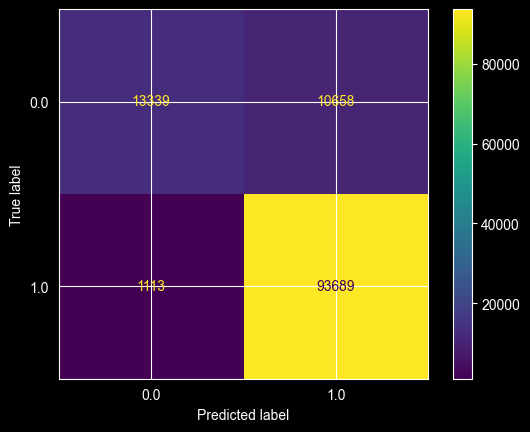

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.56      0.69     23997
         1.0       0.90      0.99      0.94     94802

    accuracy                           0.90    118799
   macro avg       0.91      0.77      0.82    118799
weighted avg       0.90      0.90      0.89    118799



## Navie Bayes

In [24]:
from sklearn.naive_bayes import GaussianNB

reg=GaussianNB()

pipe1=Pipeline([
    ("transformer",transformer),
    ("clf",reg)
])
pipe1.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('ohe_col', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
y_pred=pipe1.predict(x_test)
accuracy_score(y_test,y_pred)

0.8438959923905084

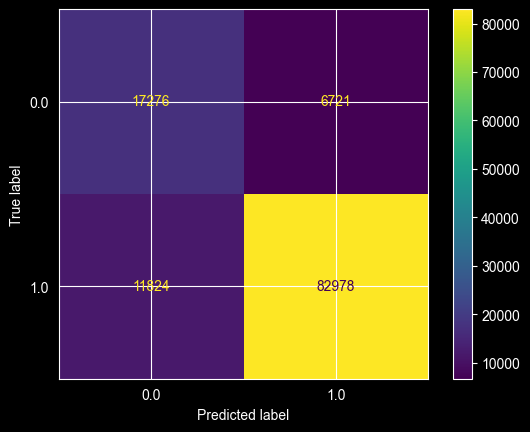

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.59      0.72      0.65     23997
         1.0       0.93      0.88      0.90     94802

    accuracy                           0.84    118799
   macro avg       0.76      0.80      0.78    118799
weighted avg       0.86      0.84      0.85    118799



### SVM Learning Curve

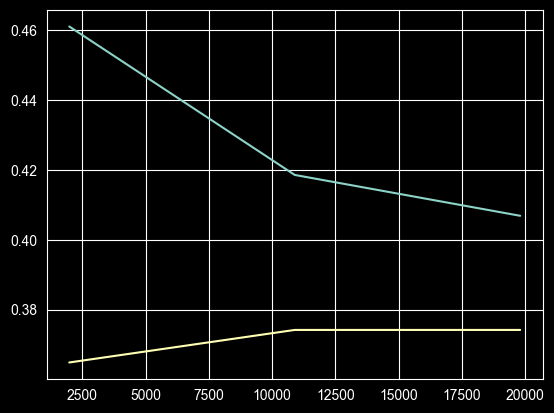

In [28]:
import numpy as np
from sklearn.model_selection import learning_curve

idx = np.random.choice(len(x), int(len(x)*0.05), replace=False)
x_small = x.iloc[idx]
y_small = y.iloc[idx]

train_sizes, train_scores, val_scores = learning_curve(
    pipe,
    x_small,
    y_small,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 3)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, val_mean)
plt.show()


### Navie Bayes Learning curve

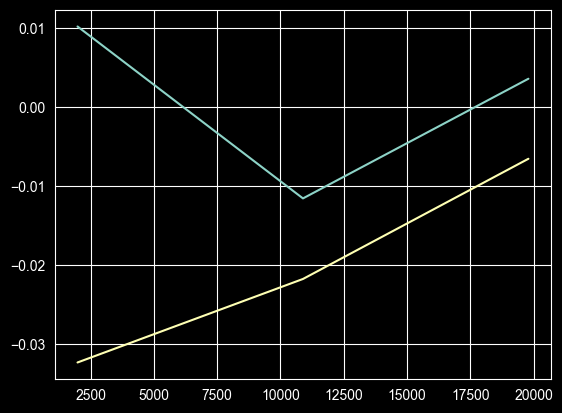

In [29]:
import numpy as np
from sklearn.model_selection import learning_curve

idx = np.random.choice(len(x), int(len(x)*0.05), replace=False)
x_small = x.iloc[idx]
y_small = y.iloc[idx]

train_sizes, train_scores, val_scores = learning_curve(
    pipe1,
    x_small,
    y_small,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 3)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, val_mean)
plt.show()


## Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier()

model=Pipeline([
    ('transformer',transformer),
    ('clf',rfc)
])
model.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('ohe_col', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.9016910916758558

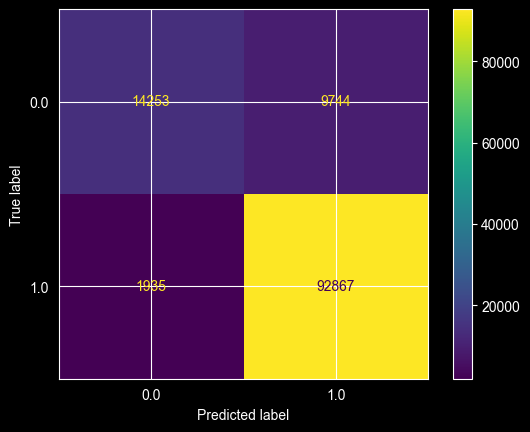

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.59      0.71     23997
         1.0       0.91      0.98      0.94     94802

    accuracy                           0.90    118799
   macro avg       0.89      0.79      0.83    118799
weighted avg       0.90      0.90      0.89    118799



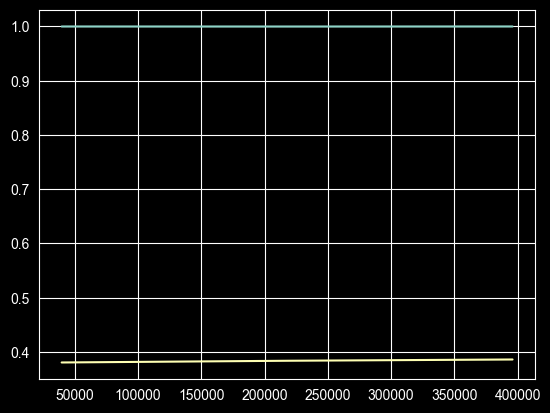

In [24]:
import numpy as np
from sklearn.model_selection import learning_curve

idx = np.random.choice(len(x), int(len(x)), replace=False)
x_small = x.iloc[idx]
y_small = y.iloc[idx]

train_sizes, train_scores, val_scores = learning_curve(
    model,
    x_small,
    y_small,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 3)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, val_mean)
plt.show()
